In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [2]:
file_path = "online_retail_II.xlsx"

df_2009 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

df = pd.concat(
    [df_2009, df_2010],
    ignore_index=True
)

print("Data loaded successfully!")
print("Shape:", df.shape)

Data loaded successfully!
Shape: (1067371, 8)


In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Revenue"] = df["Quantity"] * df["Price"]

sales_df = df[
    (df["Quantity"] > 0) &
    (df["Price"] > 0)
].copy()

print("Sales data prepared successfully!")
print("Sales rows:", len(sales_df))

Sales data prepared successfully!
Sales rows: 1041671


In [4]:
sales_df[["Quantity", "Price", "Revenue"]].describe()



,Quantity,Price,Revenue
count,1.041671e+06,1.041671e+06,1.041671e+06
mean,1.096345e+01,4.077038e+00,2.013397e+01
std,1.265149e+02,5.144898e+01,2.031167e+02
min,1.000000e+00,1.000000e-03,1.000000e-03
25%,1.000000e+00,1.250000e+00,3.900000e+00
50%,3.000000e+00,2.100000e+00,9.960000e+00
75%,1.000000e+01,4.130000e+00,1.770000e+01
max,8.099500e+04,2.511109e+04,1.684696e+05


In [5]:
uk_revenue = sales_df[
    sales_df["Country"] == "United Kingdom"
]["Revenue"]

non_uk_revenue = sales_df[
    sales_df["Country"] != "United Kingdom"
]["Revenue"]

print("UK transactions:", len(uk_revenue))
print("Non-UK transactions:", len(non_uk_revenue))

print("\nUK mean revenue:", uk_revenue.mean())
print("Non-UK mean revenue:", non_uk_revenue.mean())

UK transactions: 958502
Non-UK transactions: 83169

UK mean revenue: 18.645085087981037
Non-UK mean revenue: 37.29294317594296


In [6]:
t_stat, p_value = stats.ttest_ind(
    uk_revenue,
    non_uk_revenue,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -47.42648645887223
P-value: 0.0


In [7]:
mean_diff = uk_revenue.mean() - non_uk_revenue.mean()

se = np.sqrt(
    uk_revenue.var(ddof=1) / len(uk_revenue) +
    non_uk_revenue.var(ddof=1) / len(non_uk_revenue)
)

df_welch = (
    (
        uk_revenue.var(ddof=1) / len(uk_revenue) +
        non_uk_revenue.var(ddof=1) / len(non_uk_revenue)
    ) ** 2
    /
    (
        (uk_revenue.var(ddof=1) / len(uk_revenue)) ** 2 / (len(uk_revenue) - 1)
        +
        (non_uk_revenue.var(ddof=1) / len(non_uk_revenue)) ** 2 / (len(non_uk_revenue) - 1)
    )
)

critical_value = stats.t.ppf(0.975, df_welch)

ci_low = mean_diff - critical_value * se
ci_high = mean_diff + critical_value * se

print("Mean difference (UK - Non-UK):", mean_diff)
print("95% Confidence Interval:")
print("Lower:", ci_low)
print("Upper:", ci_high)

Mean difference (UK - Non-UK): -18.64785808796192
95% Confidence Interval:
Lower: -19.41851178498307
Upper: -17.877204390940772


In [8]:
alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print("There is statistically significant evidence that mean transaction revenue")
    print("differs between UK and Non-UK transactions.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("There is not enough statistical evidence to conclude that mean transaction")
    print("revenue differs between UK and Non-UK transactions.")

Decision: Reject the null hypothesis.
There is statistically significant evidence that mean transaction revenue
differs between UK and Non-UK transactions.


In [9]:
sales_df["CountryGroup"] = np.where(
    sales_df["Country"] == "United Kingdom",
    "United Kingdom",
    "Non-UK"
)

print(sales_df["CountryGroup"].value_counts())

CountryGroup
United Kingdom    958502
Non-UK             83169
Name: count, dtype: int64


findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmti10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


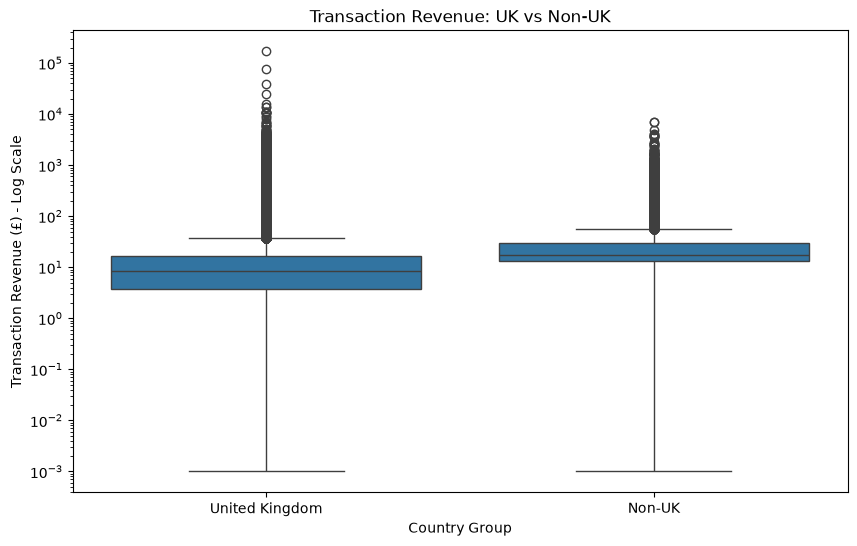

In [10]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=sales_df,
    x="CountryGroup",
    y="Revenue"
)

plt.yscale("log")
plt.title("Transaction Revenue: UK vs Non-UK")
plt.xlabel("Country Group")
plt.ylabel("Transaction Revenue (£) - Log Scale")

plt.show()

In [11]:
anova_countries = [
    "United Kingdom",
    "EIRE",
    "Netherlands",
    "Germany",
    "France"
]

anova_df = sales_df[
    sales_df["Country"].isin(anova_countries)
].copy()

print("ANOVA dataset shape:", anova_df.shape)
print("\nTransactions by country:")
print(anova_df["Country"].value_counts())

ANOVA dataset shape: (1011573, 10)

Transactions by country:
Country
United Kingdom    958502
EIRE               17349
Germany            16694
France             13940
Netherlands         5088
Name: count, dtype: int64


In [12]:
anova_df["LogRevenue"] = np.log1p(anova_df["Revenue"])

print(anova_df[["Country", "Revenue", "LogRevenue"]].head())

          Country  Revenue  LogRevenue
0  United Kingdom     83.4    4.435567
1  United Kingdom     81.0    4.406719
2  United Kingdom     81.0    4.406719
3  United Kingdom    100.8    4.623010
4  United Kingdom     30.0    3.433987


In [13]:
uk = anova_df[anova_df["Country"] == "United Kingdom"]["LogRevenue"]
eire = anova_df[anova_df["Country"] == "EIRE"]["LogRevenue"]
netherlands = anova_df[anova_df["Country"] == "Netherlands"]["LogRevenue"]
germany = anova_df[anova_df["Country"] == "Germany"]["LogRevenue"]
france = anova_df[anova_df["Country"] == "France"]["LogRevenue"]

f_stat, anova_p_value = stats.f_oneway(
    uk,
    eire,
    netherlands,
    germany,
    france
)

print("F-statistic:", f_stat)
print("ANOVA p-value:", anova_p_value)

F-statistic: 9855.820706694738
ANOVA p-value: 0.0


In [14]:
alpha = 0.05

print("Significance level (alpha):", alpha)

if anova_p_value < alpha:
    print("\nDecision: Reject the null hypothesis.")
    print("There is statistically significant evidence that")
    print("mean transaction revenue differs among the five countries.")
else:
    print("\nDecision: Fail to reject the null hypothesis.")
    print("There is not enough statistical evidence to conclude that")
    print("mean transaction revenue differs among the five countries.")

Significance level (alpha): 0.05

Decision: Reject the null hypothesis.
There is statistically significant evidence that
mean transaction revenue differs among the five countries.


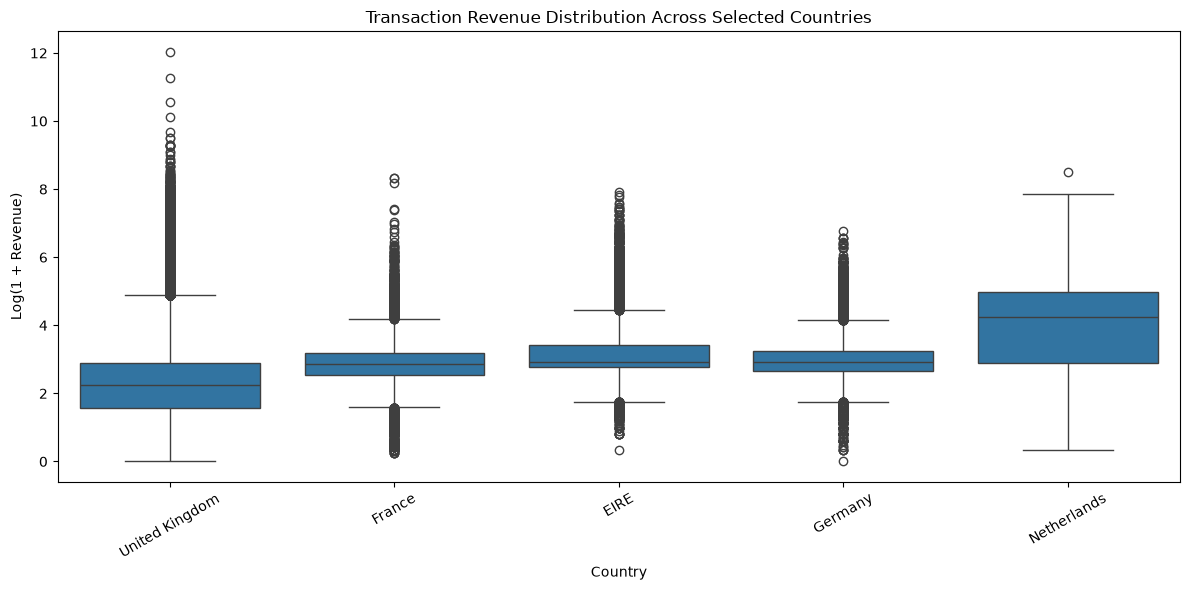

In [15]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=anova_df,
    x="Country",
    y="LogRevenue"
)

plt.title("Transaction Revenue Distribution Across Selected Countries")
plt.xlabel("Country")
plt.ylabel("Log(1 + Revenue)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [16]:
df["Cancelled"] = df["Invoice"].astype(str).str.startswith("C")

print(df["Cancelled"].value_counts())

Cancelled
False    1047877
True       19494
Name: count, dtype: int64


In [17]:
chi_countries = [
    "United Kingdom",
    "EIRE",
    "Netherlands",
    "Germany",
    "France"
]

chi_df = df[
    df["Country"].isin(chi_countries)
].copy()

contingency_table = pd.crosstab(
    chi_df["Country"],
    chi_df["Cancelled"]
)

contingency_table.columns = [
    "Not Cancelled",
    "Cancelled"
]

print(contingency_table)

                Not Cancelled  Cancelled
Country                                 
EIRE                    17354        512
France                  13941        389
Germany                 16703        921
Netherlands              5093         47
United Kingdom         964680      16650


In [18]:
chi2_stat, chi2_p_value, degrees_of_freedom, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-Square statistic:", chi2_stat)
print("P-value:", chi2_p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-Square statistic: 1444.0929074823212
P-value: 1.8983472732683e-311
Degrees of freedom: 4


In [19]:
alpha = 0.05

print("Significance level (alpha):", alpha)

if chi2_p_value < alpha:
    print("\nDecision: Reject the null hypothesis.")
    print("There is statistically significant evidence of an association")
    print("between country and cancellation status.")
else:
    print("\nDecision: Fail to reject the null hypothesis.")
    print("There is not enough statistical evidence to conclude that")
    print("country and cancellation status are associated.")

Significance level (alpha): 0.05

Decision: Reject the null hypothesis.
There is statistically significant evidence of an association
between country and cancellation status.


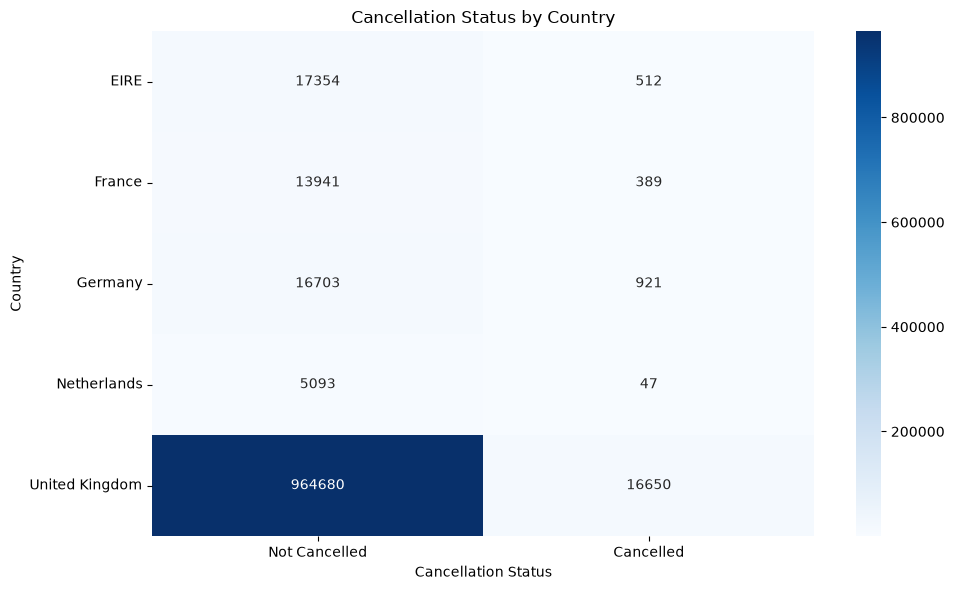

In [20]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    contingency_table,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Cancellation Status by Country")
plt.xlabel("Cancellation Status")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [21]:
expected_table = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print("Expected frequencies:")
print(expected_table.round(2))

Expected frequencies:
                Not Cancelled  Cancelled
Country                                 
EIRE                 17546.73     319.27
France               14073.92     256.08
Germany              17309.05     314.95
Netherlands           5048.15      91.85
United Kingdom      963793.16   17536.84


In [22]:
results_summary = pd.DataFrame({
    "Test": [
        "Welch Independent t-test",
        "One-Way ANOVA",
        "Chi-Square Test"
    ],
    "Test Statistic": [
        t_stat,
        f_stat,
        chi2_stat
    ],
    "P-value": [
        p_value,
        anova_p_value,
        chi2_p_value
    ],
    "Alpha": [
        0.05,
        0.05,
        0.05
    ]
})

results_summary

,Test,Test Statistic,P-value,Alpha
0,Welch Independent t-test,-47.426486,0.000000e+00,0.05
1,One-Way ANOVA,9855.820707,0.000000e+00,0.05
2,Chi-Square Test,1444.092907,1.898347e-311,0.05


In [23]:
id="a7k3pd"
results_summary["Decision"] = results_summary["P-value"].apply(
    lambda p: "Reject H0" if p < 0.05 else "Fail to Reject H0"
)

results_summary

,Test,Test Statistic,P-value,Alpha,Decision
0,Welch Independent t-test,-47.426486,0.000000e+00,0.05,Reject H0
1,One-Way ANOVA,9855.820707,0.000000e+00,0.05,Reject H0
2,Chi-Square Test,1444.092907,1.898347e-311,0.05,Reject H0


In [24]:
results_summary["Significance"] = results_summary["P-value"].apply(
    lambda p: "Statistically Significant" if p < 0.05 else "Not Statistically Significant"
)

results_summary

,Test,Test Statistic,P-value,Alpha,Decision,Significance
0,Welch Independent t-test,-47.426486,0.000000e+00,0.05,Reject H0,Statistically Significant
1,One-Way ANOVA,9855.820707,0.000000e+00,0.05,Reject H0,Statistically Significant
2,Chi-Square Test,1444.092907,1.898347e-311,0.05,Reject H0,Statistically Significant


In [25]:
country_means = (
    anova_df
    .groupby("Country")["LogRevenue"]
    .mean()
    .sort_values(ascending=False)
)

print("Mean Log Revenue by Country:")
print(country_means)

Mean Log Revenue by Country:
Country
Netherlands       3.957508
EIRE              3.131612
Germany           2.992296
France            2.906432
United Kingdom    2.285037
Name: LogRevenue, dtype: float64


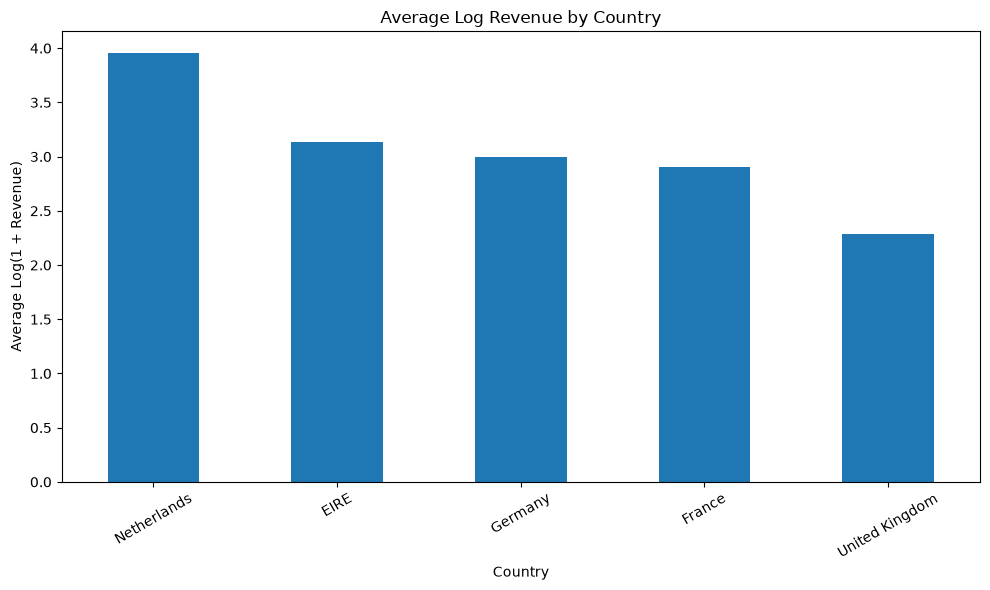

In [26]:
plt.figure(figsize=(10, 6))

country_means.plot(kind="bar")

plt.title("Average Log Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Average Log(1 + Revenue)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [27]:
print("STATISTICAL ANALYSIS SUMMARY")
print("=" * 50)

print("\n1. UK vs Non-UK Revenue — Welch t-test")
if p_value < 0.05:
    print("Result: Statistically significant difference in mean revenue.")
else:
    print("Result: No statistically significant difference in mean revenue.")

print("\n2. Revenue Across Five Countries — One-Way ANOVA")
if anova_p_value < 0.05:
    print("Result: Statistically significant difference among country means.")
else:
    print("Result: No statistically significant difference among country means.")

print("\n3. Country vs Cancellation — Chi-Square Test")
if chi2_p_value < 0.05:
    print("Result: Statistically significant association between country and cancellation.")
else:
    print("Result: No statistically significant association between country and cancellation.")

STATISTICAL ANALYSIS SUMMARY

1. UK vs Non-UK Revenue — Welch t-test
Result: Statistically significant difference in mean revenue.

2. Revenue Across Five Countries — One-Way ANOVA
Result: Statistically significant difference among country means.

3. Country vs Cancellation — Chi-Square Test
Result: Statistically significant association between country and cancellation.


In [28]:
id="k9m3qt"
results_summary["Interpretation"] = results_summary["P-value"].apply(
    lambda p: "Evidence of a statistically significant effect/association."
    if p < 0.05
    else "Insufficient evidence of a statistically significant effect/association."
)

results_summary

,Test,Test Statistic,P-value,Alpha,Decision,Significance,Interpretation
0,Welch Independent t-test,-47.426486,0.000000e+00,0.05,Reject H0,Statistically Significant,Evidence of a statistically significant effect...
1,One-Way ANOVA,9855.820707,0.000000e+00,0.05,Reject H0,Statistically Significant,Evidence of a statistically significant effect...
2,Chi-Square Test,1444.092907,1.898347e-311,0.05,Reject H0,Statistically Significant,Evidence of a statistically significant effect...


In [29]:
print("STATISTICAL ASSUMPTIONS AND LIMITATIONS")
print("=" * 55)

print("""
1. The transaction revenue data is highly right-skewed, so a log transformation
   was used for the ANOVA analysis.

2. The Welch independent t-test was used because it does not require equal
   variances between the UK and Non-UK groups.

3. The ANOVA compares the five selected countries using log-transformed revenue.

4. The Chi-Square test evaluates whether country and cancellation status are
   independent.

5. The dataset contains a very large number of transactions. Therefore, even
   relatively small differences can become statistically significant.

6. Statistical significance does not necessarily mean that the observed
   difference is large or practically important.

7. The analysis shows association and statistical differences, but it does not
   prove that one variable causes another.
""")

STATISTICAL ASSUMPTIONS AND LIMITATIONS

1. The transaction revenue data is highly right-skewed, so a log transformation
   was used for the ANOVA analysis.

2. The Welch independent t-test was used because it does not require equal
   variances between the UK and Non-UK groups.

3. The ANOVA compares the five selected countries using log-transformed revenue.

4. The Chi-Square test evaluates whether country and cancellation status are
   independent.

5. The dataset contains a very large number of transactions. Therefore, even
   relatively small differences can become statistically significant.

6. Statistical significance does not necessarily mean that the observed
   difference is large or practically important.

7. The analysis shows association and statistical differences, but it does not
   prove that one variable causes another.



# Week 3: Statistical Analysis and Hypothesis Testing

## 1. Introduction

This project applies statistical analysis and hypothesis testing to the Online Retail II dataset. The purpose of the analysis is to investigate whether transaction revenue differs between UK and Non-UK transactions, whether transaction revenue differs across selected countries, and whether country is associated with cancellation status.

The analysis uses Python libraries including Pandas, NumPy, SciPy, Matplotlib, and Seaborn. Three statistical techniques are applied: Welch's Independent t-test, One-Way ANOVA, and the Chi-Square Test of Independence.

A significance level of 0.05 is used throughout the hypothesis testing process. The results are supported with appropriate visualizations to make the statistical findings easier to understand.

## 2. Research Questions and Hypotheses

### Hypothesis 1: UK vs Non-UK Transaction Revenue

**Null Hypothesis (H₀):** There is no statistically significant difference in mean transaction revenue between UK and Non-UK transactions.

**Alternative Hypothesis (H₁):** There is a statistically significant difference in mean transaction revenue between UK and Non-UK transactions.

**Statistical Test:** Welch's Independent Samples t-test.

---

### Hypothesis 2: Revenue Across Countries

**Null Hypothesis (H₀):** The mean transaction revenue is the same across the selected countries: United Kingdom, EIRE, Netherlands, Germany, and France.

**Alternative Hypothesis (H₁):** At least one country's mean transaction revenue differs from the others.

**Statistical Test:** One-Way ANOVA.

---

### Hypothesis 3: Country and Cancellation Status

**Null Hypothesis (H₀):** Country and cancellation status are independent.

**Alternative Hypothesis (H₁):** Country and cancellation status are associated.

**Statistical Test:** Chi-Square Test of Independence.

### Significance Level

A significance level of **α = 0.05** is used for all three statistical tests.

## 3. Methodology

The Online Retail II dataset contains transaction-level information such as invoice number, product description, quantity, invoice date, unit price, customer ID, and country.

The two available yearly sheets were combined into a single dataset. The invoice date was converted into a proper datetime format, and transaction revenue was calculated as:

**Revenue = Quantity × Price**

For the revenue-based analyses, only transactions with positive quantity and positive price were retained. This produced the sales dataset used for the t-test and ANOVA.

For the Welch t-test, transaction revenue was compared between United Kingdom and Non-UK transactions.

For the One-Way ANOVA, five selected countries were analysed: United Kingdom, EIRE, Netherlands, Germany, and France. Because transaction revenue is strongly right-skewed, `log(1 + Revenue)` was used for the ANOVA analysis.

For the Chi-Square Test of Independence, the original dataset was used so that cancelled transactions were retained. Cancellation status was identified from invoice numbers beginning with the letter "C".

The analysis was performed using Pandas, NumPy, SciPy, Matplotlib, and Seaborn. A significance level of 0.05 was used for hypothesis testing.

## 4. Statistical Results and Interpretation

### 4.1 Welch's Independent t-test

The Welch independent t-test was used to compare the mean transaction revenue of UK and Non-UK transactions.

The test statistic and p-value obtained from the Python analysis are reported in the corresponding output above. The 95% confidence interval was also calculated for the difference in mean revenue.

A p-value below 0.05 indicates statistically significant evidence of a difference in mean transaction revenue between the two groups. A p-value equal to or above 0.05 indicates insufficient evidence to conclude that the group means differ.

The box plot provides a visual comparison of the revenue distributions between UK and Non-UK transactions. A logarithmic scale was used because transaction revenue contains substantial right-skewness and extreme values.

### 4.2 One-Way ANOVA

The One-Way ANOVA was used to compare transaction revenue across the United Kingdom, EIRE, Netherlands, Germany, and France.

The analysis was performed using log-transformed revenue to reduce the influence of extreme transaction values.

A p-value below 0.05 indicates statistically significant evidence that at least one country's mean revenue differs from the others. However, ANOVA by itself does not identify which specific country pairs differ.

The box plot and average log-revenue chart provide visual support for comparing the five country groups.

### 4.3 Chi-Square Test of Independence

The Chi-Square Test of Independence was used to examine the relationship between country and cancellation status.

The contingency table shows the observed numbers of cancelled and non-cancelled transactions for each selected country.

A p-value below 0.05 indicates statistically significant evidence of an association between country and cancellation status. A p-value equal to or above 0.05 indicates insufficient evidence to conclude that the two variables are associated.

The heatmap provides a visual representation of the cancellation patterns across the selected countries.

## 5. Business Implications

The statistical analysis provides useful information for understanding customer transactions across different geographic markets.

The UK vs Non-UK comparison helps determine whether transaction revenue patterns differ between the company's main domestic market and its international customers. This information may support decisions related to market segmentation, pricing strategies, and international expansion.

The ANOVA analysis examines whether transaction revenue varies across major countries. If statistically significant differences are observed, the business can further investigate individual markets to understand differences in customer purchasing behaviour and transaction value.

The cancellation analysis is also important from an operational perspective. An association between country and cancellation status may indicate that cancellation behaviour differs across markets. Businesses can investigate possible factors such as delivery issues, product availability, customer expectations, or order-processing problems.

However, statistical significance alone should not be treated as proof of business importance or causation. The size of the observed differences and the practical context should also be considered before making business decisions.

## 6. Limitations

The analysis has several limitations that should be considered when interpreting the results.

1. The transaction revenue distribution is highly right-skewed and contains extreme values. A log transformation was therefore used for the ANOVA analysis.

2. The large number of observations means that relatively small differences can produce statistically significant p-values.

3. The ANOVA indicates whether at least one group differs, but it does not identify the specific pairs of countries that differ. Post-hoc tests would be required for that purpose.

4. The Chi-Square analysis identifies an association between categorical variables but does not establish a causal relationship.

5. The analysis focuses on selected countries rather than every country in the dataset for the ANOVA and Chi-Square tests.

6. Statistical significance should be considered together with practical business importance before drawing conclusions.

7. Customer-level analyses may be affected by missing Customer ID values in the original dataset.

## 7. Conclusion

This project applied statistical analysis and hypothesis testing to the Online Retail II dataset to investigate differences in transaction revenue and cancellation behaviour.

Three statistical methods were used: Welch's Independent t-test, One-Way ANOVA, and the Chi-Square Test of Independence. Each test addressed a different research question and was supported by appropriate visualizations.

The Welch t-test examined whether transaction revenue differed between UK and Non-UK transactions. The One-Way ANOVA examined differences in transaction revenue across five selected countries. The Chi-Square test examined whether country and cancellation status were statistically associated.

The analysis demonstrates how statistical hypothesis testing can be used to move beyond simple descriptive statistics and evaluate whether observed patterns are supported by statistical evidence.

Overall, the project provides a structured statistical framework for understanding transaction behaviour in the Online Retail II dataset. The findings should be interpreted together with the limitations of the dataset, the statistical assumptions, and practical business context.

## 8. Estimated Workload

The estimated time spent on this project is approximately **32–35 hours**, including:

- Dataset preparation and cleaning
- Exploratory analysis
- Hypothesis formulation
- Statistical test selection
- Welch's t-test
- One-Way ANOVA
- Chi-Square Test of Independence
- Confidence interval calculation
- Visualization development
- Statistical interpretation
- Documentation and report preparation

## 9. References

1. UCI Machine Learning Repository – Online Retail II Dataset.
2. Pandas Documentation – Data manipulation and analysis in Python.
3. SciPy Documentation – Statistical tests and probability distributions.
4. Matplotlib Documentation – Data visualization in Python.
5. Seaborn Documentation – Statistical data visualization.